# HowFar — Nearwork Exposure Analysis (2026-06-07)

This notebook produces the appendix figures for the nearwork exposure analysis. Input: `OPTODATA_7.06.csv` (7 June 2026, 47 136 samples at 1 Hz, 13.09 h). Figures are saved to `figs/app/`.

## 0. Setup
Mounts Google Drive, installs fonts, configures the plot style and colour palette, and creates output directories.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run(['apt-get', 'install', '-y', 'msttcorefonts'], capture_output=True)
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)
import matplotlib.pyplot as plt
plt.style.use("/content/drive/MyDrive/Bachelor's Thesis/howfar.mplstyle")

C_HF     = '#51568D'  # Dusty Grape     — primary signal / distance
C_BLUE   = '#546FA5'  # Smart Blue      — secondary / processed signal
C_MAUVE  = '#D2B8FF'  # Mauve           — tertiary
C_OUT    = '#FC9494'  # Grapefruit Pink — danger / warning (replaces red)
C_WARM   = '#FCBD9F'  # Warm Peach      — lux / illuminance signal
C_GOLD   = '#FCE3A9'  # Soft Gold       — moderate-warning threshold lines
C_MINT   = '#C9FCB1'  # Mint Green      — protective / safe thresholds
C_PURPLE = '#4B3D6F'  # Deep Purple     — vergence demand

Mounted at /content/drive


In [2]:
import os
output_dirs = ['figs/app']
for d in output_dirs:
    os.makedirs(d, exist_ok=True)
print("Output directories ready:", output_dirs)

Output directories ready: ['figs/app']


## 1. Load Data from Google Drive
Downloads `OPTODATA_7.06.csv` from Google Drive and normalises its columns (`timestamp` → `epoch_millis`, `tof_distance_mm` → `distance_cm`, `alx_lx` → `illumination_lux`) for the rest of the pipeline.

In [3]:
import subprocess, sys, os
try:
    import gdown
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
    import gdown

import pandas as pd

FILE_ID   = '1YTVCbZ9Kfdh8a7Fd_4TGRpvE1iqyFhnj'
SRC_NAME  = 'OPTODATA_7.06.csv'
NORM_NAME = 'nearwork_raw_OPTODATA_7.06.csv'   # prefix required by downstream cells

if not os.path.exists(SRC_NAME):
    print("Downloading from Google Drive...")
    gdown.download(id=FILE_ID, output=SRC_NAME, quiet=False)
else:
    print(f"Using cached: {SRC_NAME}")

_df = pd.read_csv(SRC_NAME)
print("\nOriginal columns:", list(_df.columns))
print("Rows            :", len(_df))
print(_df.head(3).to_string())

_df = _df.rename(columns={
    'timestamp':       'epoch_millis',
    'tof_distance_mm': 'distance_cm',
    'alx_lx':          'illumination_lux',
})
_df['epoch_millis'] = (_df['epoch_millis'] * 1000).astype('int64')
_df['distance_cm']  =  _df['distance_cm']  / 10.0

_df.to_csv(NORM_NAME, index=False)

paths = [os.path.abspath(NORM_NAME)]
print(f"\nNormalised file : {NORM_NAME}")
print(f"Distance range  : {_df['distance_cm'].min():.1f}\u2013{_df['distance_cm'].max():.1f} cm")
print(f"Lux range       : {_df['illumination_lux'].min():.1f}\u2013{_df['illumination_lux'].max():.1f}")
print(f"Epoch range     : {_df['epoch_millis'].iloc[0]} \u2013 {_df['epoch_millis'].iloc[-1]}")

Downloading...
From: https://drive.google.com/uc?id=1YTVCbZ9Kfdh8a7Fd_4TGRpvE1iqyFhnj
To: /content/OPTODATA_7.06.csv
100%|██████████| 407k/407k [00:00<00:00, 9.86MB/s]


Original columns: ['datetime', 'timestamp', 'alx_lx', 'tof_distance_mm']
Rows            : 9428
              datetime   timestamp  alx_lx  tof_distance_mm
0  2026-06-07T11:52:21  1780825941  140.48             1059
1  2026-06-07T11:52:26  1780825946  153.92              981
2  2026-06-07T11:52:31  1780825951  101.12                0

Normalised file : nearwork_raw_OPTODATA_7.06.csv
Distance range  : 0.0–136.2 cm
Lux range       : 0.0–12088.3
Epoch range     : 1780825941000 – 1780873076000


## 2. Load & Initial Distance Plot
Downsamples the raw signal and plots working distance over time.

Saved: figs/app/fig_app_nw_01_distance.pdf


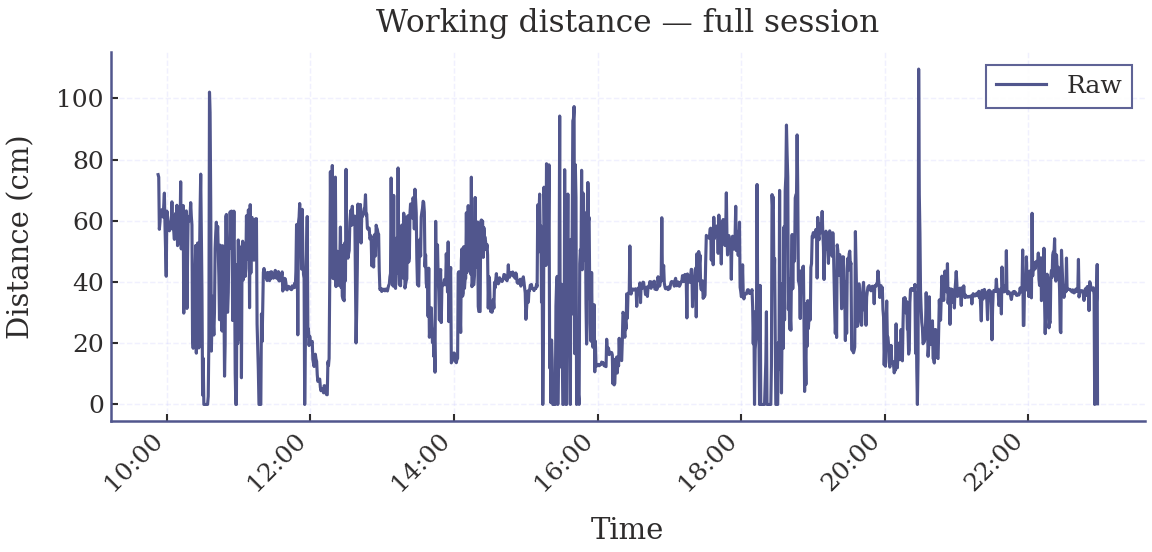

Loaded: {'raw': 'nearwork_raw_OPTODATA_7.06.csv', 'processed': None}


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

raw_path  = next((p for p in paths if os.path.basename(p).lower().startswith("nearwork_raw_")),  None)
proc_path = next((p for p in paths if os.path.basename(p).lower().startswith("nearwork_processed_")), None)

def load_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "epoch_millis" not in df.columns:
        raise ValueError(f"{os.path.basename(path)} missing column: epoch_millis")
    if "distance_cm" not in df.columns:
        raise ValueError(f"{os.path.basename(path)} missing column: distance_cm")
    return df

def prep(df: pd.DataFrame) -> pd.DataFrame:
    return df.sort_values("epoch_millis").copy()

def downsample(df: pd.DataFrame, max_points: int = 1500) -> pd.DataFrame:
    if len(df) <= max_points:
        return df
    first = int(df["epoch_millis"].iloc[0])
    last  = int(df["epoch_millis"].iloc[-1])
    span  = max(last - first, 1)
    bucket_ms = max(int(span / max_points), 1)
    b = ((df["epoch_millis"] - first) // bucket_ms).astype(int)
    out = df.groupby(b, as_index=False).agg({
        "epoch_millis": "mean",
        "distance_cm": "mean",
        **({"illumination_lux": "mean"} if "illumination_lux" in df.columns else {})
    })
    out["epoch_millis"] = out["epoch_millis"].round().astype("int64")
    return out

gap_ms = 60_000
series_ds = []
if raw_path:
    raw_ds = downsample(prep(load_csv(raw_path)), 1500).reset_index(drop=True)
    raw_ds['datetime'] = pd.to_datetime(raw_ds['epoch_millis'], unit='ms', utc=True)
    series_ds.append(("Raw", raw_ds))
if proc_path:
    proc_ds = downsample(prep(load_csv(proc_path)), 1500).reset_index(drop=True)
    proc_ds['datetime'] = pd.to_datetime(proc_ds['epoch_millis'], unit='ms', utc=True)
    series_ds.append(("Processed", proc_ds))
if not series_ds:
    raise ValueError("Upload nearwork_raw_YYYY-MM-DD.csv and/or nearwork_processed_YYYY-MM-DD.csv")

_series_colors = [C_HF, C_BLUE]
fig, ax = plt.subplots(figsize=(8, 4))
for (label, df_s), col in zip(series_ds, _series_colors):
    ax.plot(df_s['datetime'], df_s['distance_cm'], color=col, linewidth=1.5, label=label)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.set_xlabel("Time", labelpad=10)
ax.set_ylabel("Distance (cm)", labelpad=10)
ax.set_title("Working distance — full session", pad=10)
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
fig.savefig('figs/app/fig_app_nw_01_distance.pdf', bbox_inches='tight', dpi=300)
print('Saved: figs/app/fig_app_nw_01_distance.pdf')
plt.show()
print("Loaded:", {"raw": os.path.basename(raw_path) if raw_path else None,
                  "processed": os.path.basename(proc_path) if proc_path else None})

## 3. Validation & Preprocessing
Sorts, deduplicates, interpolates to a uniform 1 Hz grid, and applies a 60-sample causal rolling mean to distance.

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

GAP_THRESHOLD_S = 10
SMOOTH_WINDOW   = 60
DIST_VALID_MIN  = 10
DIST_VALID_MAX  = 200
LUX_VALID_MIN   = 0
LUX_VALID_MAX   = 50_000

raw_path  = next((p for p in paths if os.path.basename(p).lower().startswith("nearwork_raw_")),  None)
proc_path = next((p for p in paths if os.path.basename(p).lower().startswith("nearwork_processed_")), None)

def load_csv(path):
    df = pd.read_csv(path)
    for col in ['epoch_millis', 'distance_cm']:
        if col not in df.columns:
            raise ValueError(f"{os.path.basename(path)} missing column: {col}")
    return df

def align_to_1hz(df, label=""):
    n0 = len(df)
    df = df.copy()
    df = df.sort_values('epoch_millis').drop_duplicates('epoch_millis', keep='last')
    dist_invalid = ~df['distance_cm'].between(DIST_VALID_MIN, DIST_VALID_MAX)
    dist_rejected = int(dist_invalid.sum())
    df.loc[dist_invalid, 'distance_cm'] = float('nan')   # NaN rather than drop — keeps lux valid
    lux_rejected = 0
    has_lux_raw = 'illumination_lux' in df.columns
    if has_lux_raw:
        lux_bad = ~df['illumination_lux'].between(LUX_VALID_MIN, LUX_VALID_MAX)
        lux_rejected = int(lux_bad.sum())
        df.loc[lux_bad, 'illumination_lux'] = float('nan')
    print(f"[{label}]  loaded: {n0}  dist-NaN'd: {dist_rejected}  "
          f"lux-NaN'd: {lux_rejected}  remaining: {len(df)}")
    first_epoch = df['epoch_millis'].iloc[0]
    t_raw  = (df['epoch_millis'].values - first_epoch) / 1000.0
    t_grid = np.arange(0, int(np.floor(t_raw[-1])) + 1, dtype=float)
    dist_interp = np.interp(t_grid, t_raw, df['distance_cm'].values)
    gaps = np.diff(t_raw)
    for idx in np.where(gaps > GAP_THRESHOLD_S)[0]:
        mask = (t_grid > t_raw[idx]) & (t_grid < t_raw[idx + 1])
        dist_interp[mask] = np.nan
    lux_interp = None
    if has_lux_raw:
        lux_interp = np.interp(t_grid, t_raw, df['illumination_lux'].values)
        for idx in np.where(gaps > GAP_THRESHOLD_S)[0]:
            mask = (t_grid > t_raw[idx]) & (t_grid < t_raw[idx + 1])
            lux_interp[mask] = np.nan
    out = pd.DataFrame({'t_sec': t_grid, 'distance_cm': dist_interp})
    if lux_interp is not None:
        out['illumination_lux'] = lux_interp
    out['distance_cm_smooth'] = out['distance_cm'].rolling(SMOOTH_WINDOW, min_periods=1).mean()
    print(f"        1 Hz grid: {len(out)} samples  ({len(out)/3600:.2f} h)  "
          f"gaps NaN'd: {int((gaps > GAP_THRESHOLD_S).sum())}")
    return out, first_epoch

raw_aligned,  first_epoch_raw  = align_to_1hz(load_csv(raw_path),  "raw")  if raw_path  else (None, None)
proc_aligned, first_epoch_proc = align_to_1hz(load_csv(proc_path), "proc") if proc_path else (None, None)

df          = proc_aligned if proc_aligned is not None else raw_aligned
first_epoch = first_epoch_proc if proc_aligned is not None else first_epoch_raw
has_lux     = 'illumination_lux' in df.columns

print(f"\nWorking dataframe: {'processed' if proc_aligned is not None else 'raw'}")
print(f"Illuminance data : {has_lux}")

[raw]  loaded: 9428  dist-NaN'd: 1200  lux-NaN'd: 0  remaining: 9428
        1 Hz grid: 47136 samples  (13.09 h)  gaps NaN'd: 0

Working dataframe: raw
Illuminance data : True


## 4. Session Overview
Prints session metadata: start time, duration, sample count, and recording coverage.

In [6]:
duration_s   = df['t_sec'].max()
duration_h   = duration_s / 3600.0
day_fraction = duration_h / 24.0
sample_count = len(df)

try:
    first_dt   = pd.to_datetime(first_epoch, unit='ms', utc=True)
    df['datetime'] = first_dt + pd.to_timedelta(df['t_sec'], unit='s')
    df['hour']     = df['datetime'].dt.hour + df['datetime'].dt.minute / 60
    use_datetime   = True
    print(f"Absolute start: {first_dt.strftime('%Y-%m-%d %H:%M:%S UTC')}")
except Exception:
    df['hour']   = (df['t_sec'] / 3600) % 24
    use_datetime = False
    print("Could not parse datetime — using relative t_sec.")

print(f"\n── Session overview ─────────────────────────────")
print(f"  Duration         : {duration_h:.2f} h  ({duration_s/60:.0f} min)")
print(f"  Day fraction     : {duration_h:.1f} / 24 h  =  {day_fraction*100:.1f}%")
print(f"  1 Hz samples     : {sample_count}")
filled = int(day_fraction * 40)
print(f"\n  Coverage  [{'█' * filled}{'░' * (40 - filled)}]  {day_fraction*100:.1f}%")

Absolute start: 2026-06-07 09:52:21 UTC

── Session overview ─────────────────────────────
  Duration         : 13.09 h  (786 min)
  Day fraction     : 13.1 / 24 h  =  54.6%
  1 Hz samples     : 47136

  Coverage  [█████████████████████░░░░░░░░░░░░░░░░░░░]  54.6%


## 5. Diopter-Hour Computation & Cumulative Curve
Trapezoidal integration of vergence demand ($D = 100/d_{\\text{cm}}$) over the session.

Total D-h     : 32.9404
Mean vergence : 2.598 D  (~38.5 cm)
Saved: figs/app/fig_app_nw_02_dh.pdf


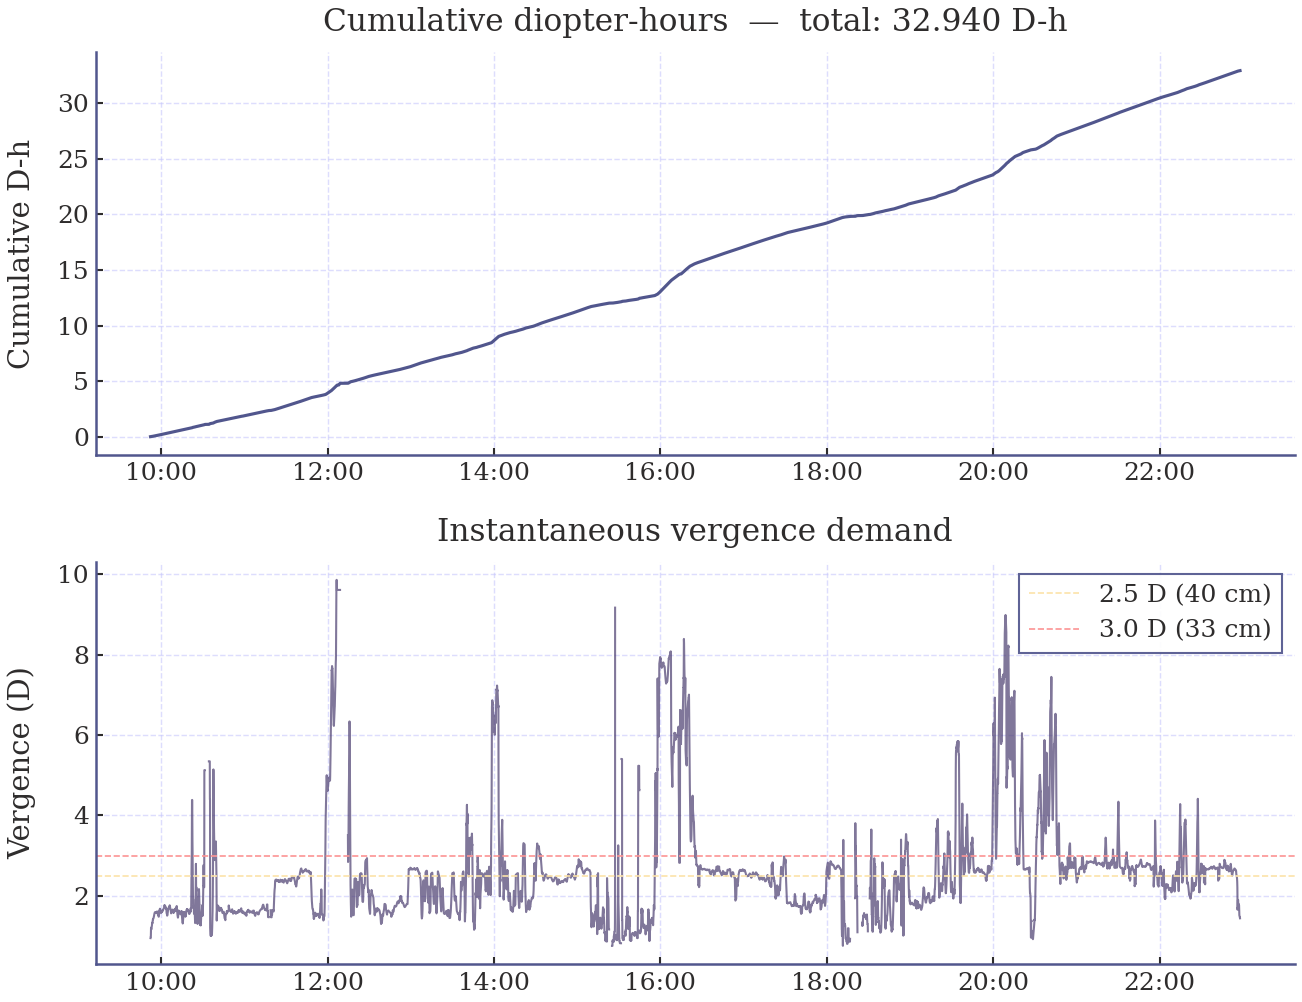

In [7]:
df['diopters'] = 1.0 / (df['distance_cm_smooth'] / 100.0)
dt_hours       = df['t_sec'].diff().fillna(0) / 3600.0
df['dh_inc']   = ((df['diopters'] + df['diopters'].shift(1)) / 2) * dt_hours
df['dh_inc']   = df['dh_inc'].fillna(0)
df['dh_cum']   = df['dh_inc'].cumsum()

dh_total      = df['dh_inc'].sum()
mean_diopters = df['diopters'].mean()

print(f"Total D-h     : {dh_total:.4f}")
print(f"Mean vergence : {mean_diopters:.3f} D  (~{100/mean_diopters:.1f} cm)")

x_ax  = df['datetime'] if use_datetime else df['t_sec']
x_fmt = mdates.DateFormatter('%H:%M') if use_datetime else None
x_lbl = '' if use_datetime else 'Seconds from session start'

fig, axes = plt.subplots(2, 1, figsize=(9, 7))
axes[0].plot(x_ax, df['dh_cum'], color=C_HF, linewidth=1.5)
axes[0].set_ylabel('Cumulative D-h', labelpad=10)
axes[0].set_title(f'Cumulative diopter-hours  —  total: {dh_total:.3f} D-h', pad=10)
if x_fmt: axes[0].xaxis.set_major_formatter(x_fmt)
axes[0].set_xlabel(x_lbl, labelpad=10)

axes[1].plot(x_ax, df['diopters'], color=C_PURPLE, linewidth=1, alpha=0.7)
axes[1].axhline(2.5, color=C_GOLD, linestyle='--', linewidth=0.8, label='2.5 D (40 cm)')
axes[1].axhline(3.0, color=C_OUT,  linestyle='--', linewidth=0.8, label='3.0 D (33 cm)')
axes[1].set_ylabel('Vergence (D)', labelpad=10)
axes[1].set_title('Instantaneous vergence demand', pad=10)
if x_fmt: axes[1].xaxis.set_major_formatter(x_fmt)
axes[1].set_xlabel(x_lbl, labelpad=10)
axes[1].legend()
plt.tight_layout()
fig.savefig('figs/app/fig_app_nw_02_dh.pdf', bbox_inches='tight', dpi=300)
print('Saved: figs/app/fig_app_nw_02_dh.pdf')
plt.show()


## 6. Illuminance Analysis
Ambient illuminance distribution against the six NRS tier thresholds.

Mean lux   : 88.5
Median lux : 66.9

  ≤55 lux  (×1.5 danger)      : 46.1%  (361.9 min)
  55–300   (×1.0 baseline)     : 51.8%
  300–1000 (×0.8 transition)   : 2.0%
  1000–3000 (×0.5 protective)  : 0.1%
  >5000    (×0.2 strong)       : 0.0%
  ≥3000 lux (outdoor): 0.0%  (0.1 min)
Saved: figs/app/fig_app_nw_03_illuminance.pdf


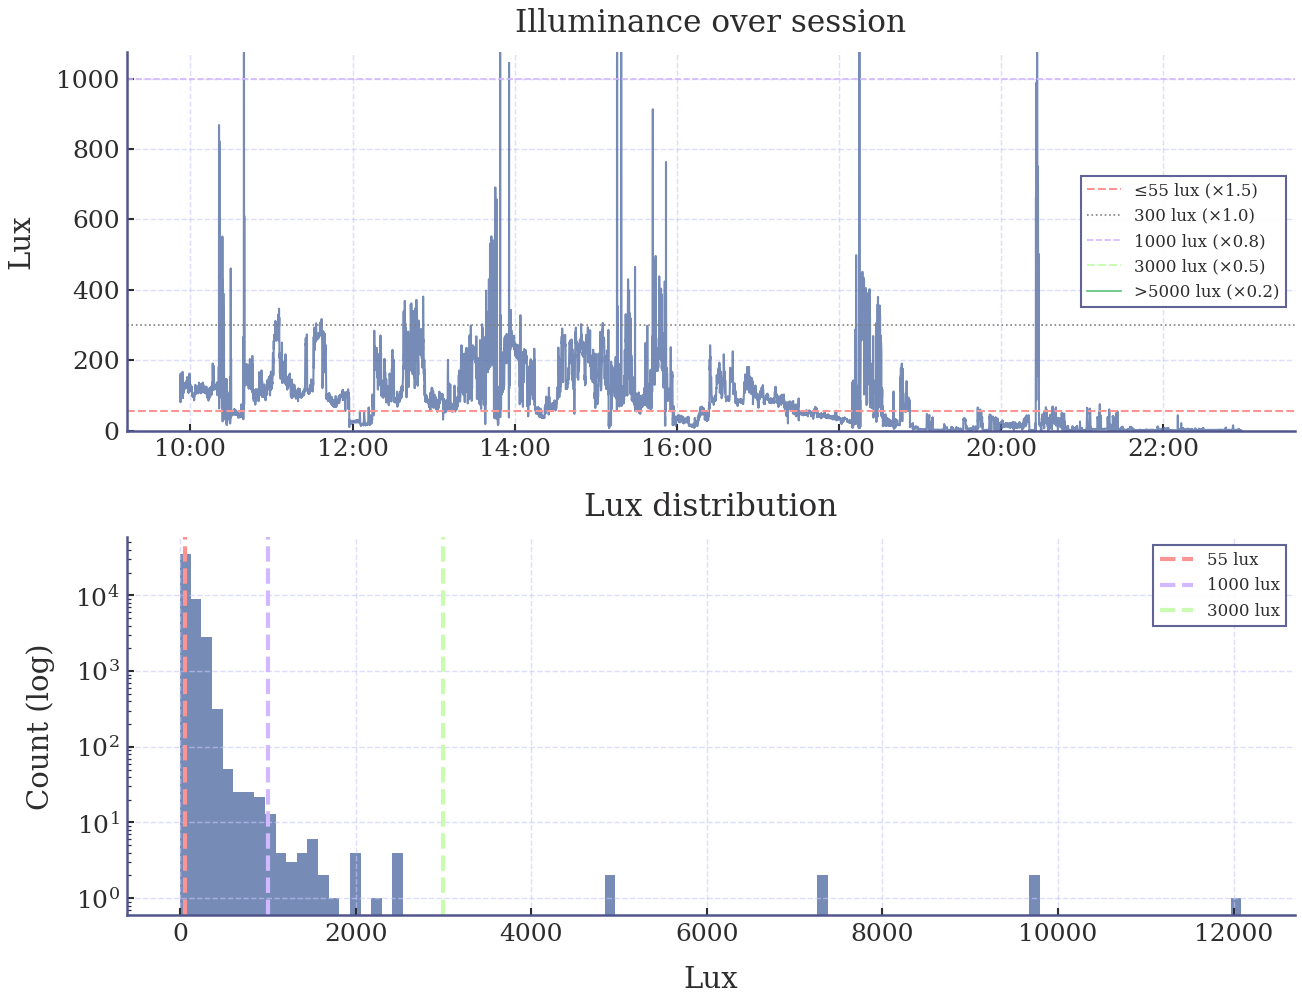

In [8]:
if not has_lux:
    print("No illumination_lux column — skipping.")
else:
    DANGER_THRESH     =    55
    BASELINE_THRESH   =   300
    TRANSITION_THRESH =  1000
    PROTECTIVE_THRESH =  3000
    STRONG_THRESH     =  5000

    lux_mean   = df['illumination_lux'].mean()
    lux_median = df['illumination_lux'].median()

    danger_frac     = (df['illumination_lux'] <= DANGER_THRESH).mean()
    baseline_frac   = df['illumination_lux'].between(DANGER_THRESH, BASELINE_THRESH, inclusive='right').mean()
    transition_frac = df['illumination_lux'].between(BASELINE_THRESH, TRANSITION_THRESH, inclusive='right').mean()
    protective_frac = df['illumination_lux'].between(TRANSITION_THRESH, PROTECTIVE_THRESH, inclusive='right').mean()
    strong_frac     = (df['illumination_lux'] > STRONG_THRESH).mean()
    outdoor_frac    = (df['illumination_lux'] >= PROTECTIVE_THRESH).mean()
    outdoor_min     = outdoor_frac * duration_h * 60
    danger_min      = danger_frac  * duration_h * 60

    print(f"Mean lux   : {lux_mean:.1f}")
    print(f"Median lux : {lux_median:.1f}")
    print()
    print(f"  ≤55 lux  (×1.5 danger)      : {danger_frac*100:.1f}%  ({danger_min:.1f} min)")
    print(f"  55–300   (×1.0 baseline)     : {baseline_frac*100:.1f}%")
    print(f"  300–1000 (×0.8 transition)   : {transition_frac*100:.1f}%")
    print(f"  1000–3000 (×0.5 protective)  : {protective_frac*100:.1f}%")
    print(f"  >5000    (×0.2 strong)       : {strong_frac*100:.1f}%")
    print(f"  ≥3000 lux (outdoor): {outdoor_frac*100:.1f}%  ({outdoor_min:.1f} min)")

    x_ax  = df['datetime'] if use_datetime else df['t_sec']
    x_fmt = mdates.DateFormatter('%H:%M') if use_datetime else None
    x_lbl = '' if use_datetime else 'Seconds from session start'

    fig, axes = plt.subplots(2, 1, figsize=(9, 7))
    axes[0].plot(x_ax, df['illumination_lux'], color=C_BLUE, linewidth=1, alpha=0.8)
    axes[0].axhline(DANGER_THRESH,     color=C_OUT,     linestyle='--', linewidth=1.0, label=f'≤{DANGER_THRESH} lux (×1.5)')
    axes[0].axhline(BASELINE_THRESH,   color='grey',    linestyle=':',  linewidth=0.8, label=f'{BASELINE_THRESH} lux (×1.0)')
    axes[0].axhline(TRANSITION_THRESH, color=C_MAUVE,   linestyle='--', linewidth=0.8, label=f'{TRANSITION_THRESH} lux (×0.8)')
    axes[0].axhline(PROTECTIVE_THRESH, color=C_MINT,    linestyle='--', linewidth=1.0, label=f'{PROTECTIVE_THRESH} lux (×0.5)')
    axes[0].axhline(STRONG_THRESH,     color='#5BBF7A', linestyle='-',  linewidth=0.8, label=f'>{STRONG_THRESH} lux (×0.2)')
    axes[0].set_ylabel('Lux', labelpad=10)
    axes[0].set_title('Illuminance over session', pad=10)
    if x_fmt: axes[0].xaxis.set_major_formatter(x_fmt)
    axes[0].set_xlabel(x_lbl, labelpad=10)
    axes[0].set_ylim(0, df['illumination_lux'].quantile(0.999) * 1.1)
    axes[0].legend(fontsize=8)

    axes[1].hist(df['illumination_lux'].dropna(), bins=100, log=True, color=C_BLUE, alpha=0.8)
    axes[1].axvline(DANGER_THRESH,     color=C_OUT,   linestyle='--', label=f'{DANGER_THRESH} lux')
    axes[1].axvline(TRANSITION_THRESH, color=C_MAUVE, linestyle='--', label=f'{TRANSITION_THRESH} lux')
    axes[1].axvline(PROTECTIVE_THRESH, color=C_MINT,  linestyle='--', label=f'{PROTECTIVE_THRESH} lux')
    axes[1].set_xlabel('Lux', labelpad=10)
    axes[1].set_ylabel('Count (log)', labelpad=10)
    axes[1].set_title('Lux distribution', pad=10)
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    fig.savefig('figs/app/fig_app_nw_03_illuminance.pdf', bbox_inches='tight', dpi=300)
print('Saved: figs/app/fig_app_nw_03_illuminance.pdf')
plt.show()


## 7. Nearwork in Low Light
Time spent within 40 cm while ambient illuminance is in the danger tier (\u226455 lux).

Nearwork (< 40 cm)             : 345.1 min
Nearwork + low light (≤55 lux) : 226.9 min
Mean lux (nearwork)              : 55.7
Mean lux (non-nearwork)          : 114.2
Saved: figs/app/fig_app_nw_04_low_light.pdf


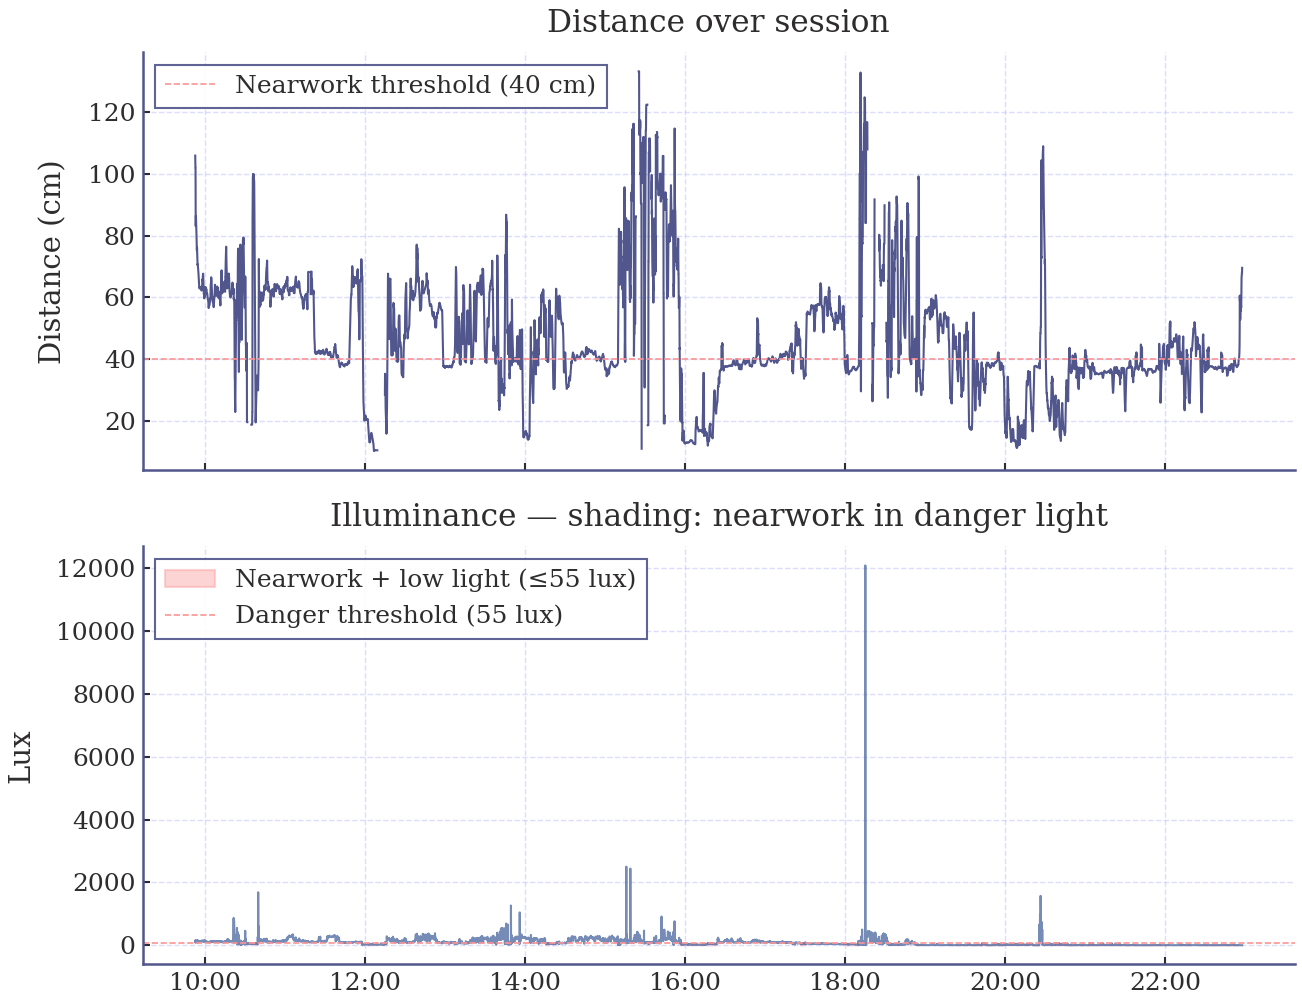

In [9]:
if not has_lux:
    print("No lux data — skipping.")
else:
    NEARWORK_THRESH  = 40
    LOW_LIGHT_THRESH = 55

    dt_sec = df['t_sec'].diff().fillna(0)
    df['is_nearwork']           = df['distance_cm_smooth'] < NEARWORK_THRESH
    df['is_low_light']          = df['illumination_lux'] <= LOW_LIGHT_THRESH
    df['is_nearwork_low_light'] = df['is_nearwork'] & df['is_low_light']

    nearwork_sec     = (df['is_nearwork'] * dt_sec).sum()
    nw_low_light_sec = (df['is_nearwork_low_light'] * dt_sec).sum()
    mean_lux_nw      = df.loc[df['is_nearwork'],  'illumination_lux'].mean()
    mean_lux_non_nw  = df.loc[~df['is_nearwork'], 'illumination_lux'].mean()

    print(f"Nearwork (< {NEARWORK_THRESH} cm)             : {nearwork_sec/60:.1f} min")
    print(f"Nearwork + low light (≤{LOW_LIGHT_THRESH} lux) : {nw_low_light_sec/60:.1f} min")
    print(f"Mean lux (nearwork)              : {mean_lux_nw:.1f}")
    print(f"Mean lux (non-nearwork)          : {mean_lux_non_nw:.1f}")

    x_ax  = df['datetime'] if use_datetime else df['t_sec']
    x_fmt = mdates.DateFormatter('%H:%M') if use_datetime else None
    x_lbl = '' if use_datetime else 'Seconds from session start'

    fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
    axes[0].plot(x_ax, df['distance_cm_smooth'], color=C_HF, linewidth=1)
    axes[0].axhline(NEARWORK_THRESH, color=C_OUT, linestyle='--', linewidth=0.8,
                    label=f'Nearwork threshold ({NEARWORK_THRESH} cm)')
    axes[0].set_ylabel('Distance (cm)', labelpad=10)
    axes[0].set_title('Distance over session', pad=10)
    axes[0].legend()

    axes[1].plot(x_ax, df['illumination_lux'], color=C_BLUE, linewidth=1, alpha=0.8)
    axes[1].fill_between(x_ax,
                         df['illumination_lux'].where(df['is_nearwork_low_light']),
                         alpha=0.4, color=C_OUT,
                         label=f'Nearwork + low light (≤{LOW_LIGHT_THRESH} lux)')
    axes[1].axhline(LOW_LIGHT_THRESH, color=C_OUT, linestyle='--', linewidth=0.8,
                    label=f'Danger threshold ({LOW_LIGHT_THRESH} lux)')
    axes[1].set_ylabel('Lux', labelpad=10)
    axes[1].set_title('Illuminance — shading: nearwork in danger light', pad=10)
    if x_fmt: axes[1].xaxis.set_major_formatter(x_fmt)
    axes[1].set_xlabel(x_lbl, labelpad=10)
    axes[1].legend()
    plt.tight_layout()
    fig.savefig('figs/app/fig_app_nw_04_low_light.pdf', bbox_inches='tight', dpi=300)
print('Saved: figs/app/fig_app_nw_04_low_light.pdf')
plt.show()


## 8. Distance Zone Analysis
Time distribution across the four NRS distance zones and continuous nearwork session detection.

── Distance zone breakdown (NRS-aligned) ────────────────────
  < 20 cm  (w_zone = 5.0) :   55.8 min  (7.1%)
  20–30 cm (w_zone = 2.5) :   39.8 min  (5.1%)
  30–50 cm (w_zone = 1.5) :  398.4 min  (50.7%)
  ≥50 cm  (w_zone = 1.0) :  266.9 min  (34.0%)

  Mean diopter demand : 2.598 D
  Time > 2.5 D        : 345.1 min
  Distance std        : 18.33 cm

── Continuous nearwork sessions ─────────────────
  Sessions detected : 69
  Longest           : 57.0 min
  Mean length       : 5.2 min
  Sessions ≥30 min  : 3
  Sessions ≥45 min  : 1
Saved: figs/app/fig_app_nw_05_zones.pdf


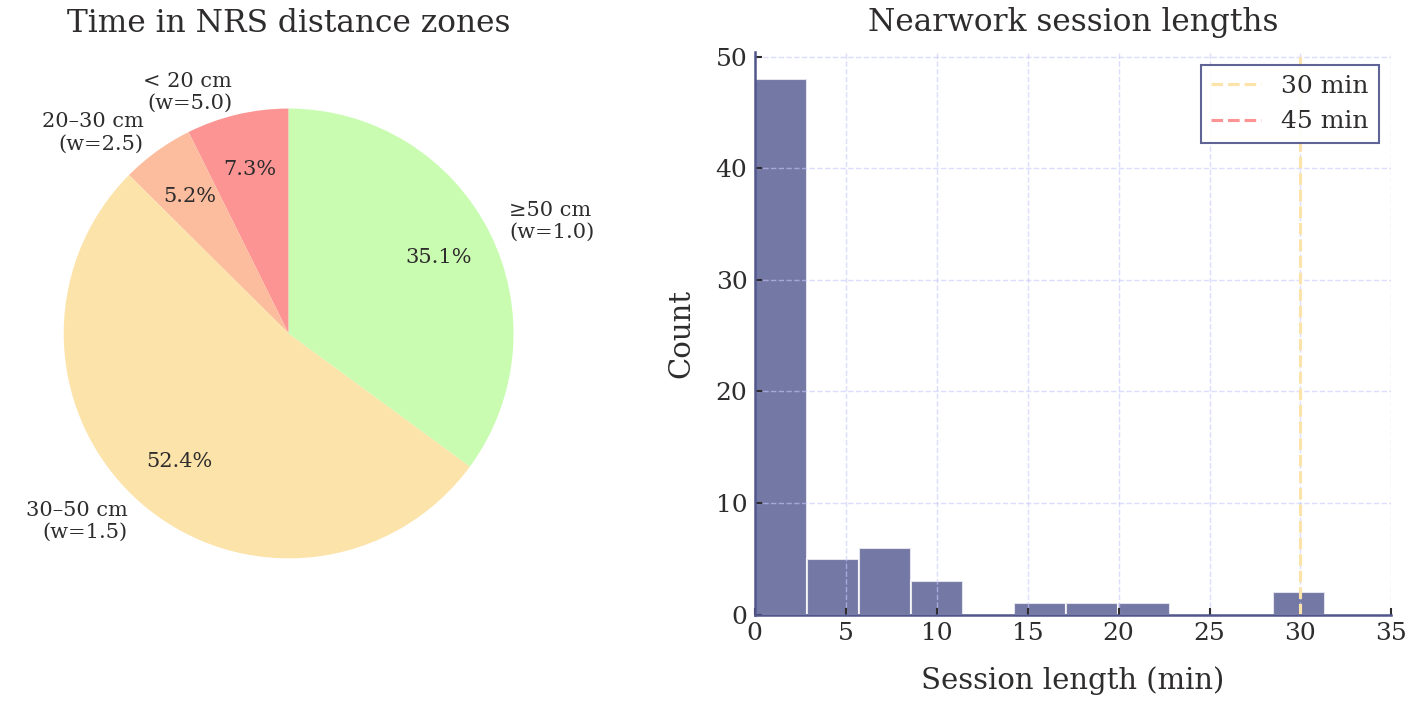

In [10]:
dt_sec = df['t_sec'].diff().fillna(0)

t_under_20 = (df['distance_cm_smooth'] < 20).mul(dt_sec).sum()
t_20_30    = df['distance_cm_smooth'].between(20, 30, inclusive='left').mul(dt_sec).sum()
t_30_50    = df['distance_cm_smooth'].between(30, 50, inclusive='left').mul(dt_sec).sum()
t_50_plus  = (df['distance_cm_smooth'] >= 50).mul(dt_sec).sum()
t_above_25D = (df['diopters'] > 2.5).mul(dt_sec).sum()
t_above_30D = (df['diopters'] > 3.0).mul(dt_sec).sum()
dist_std    = df['distance_cm_smooth'].std()
dist_cv     = dist_std / df['distance_cm_smooth'].mean()
total_sec   = dt_sec.sum()

print("── Distance zone breakdown (NRS-aligned) ────────────────────")
print(f"  < 20 cm  (w_zone = 5.0) : {t_under_20/60:6.1f} min  ({t_under_20/total_sec*100:.1f}%)")
print(f"  20–30 cm (w_zone = 2.5) : {t_20_30/60:6.1f} min  ({t_20_30/total_sec*100:.1f}%)")
print(f"  30–50 cm (w_zone = 1.5) : {t_30_50/60:6.1f} min  ({t_30_50/total_sec*100:.1f}%)")
print(f"  ≥50 cm  (w_zone = 1.0) : {t_50_plus/60:6.1f} min  ({t_50_plus/total_sec*100:.1f}%)")
print()
print(f"  Mean diopter demand : {df['diopters'].mean():.3f} D")
print(f"  Time > 2.5 D        : {t_above_25D/60:.1f} min")
print(f"  Distance std        : {dist_std:.2f} cm")

NEARWORK_DIST_THRESH = 40
SESSION_BREAK_S      = 60
WARN_THRESHOLD_S     = 30 * 60
HIGH_THRESHOLD_S     = 45 * 60

is_nw      = (df['distance_cm_smooth'] < NEARWORK_DIST_THRESH).values
t_sec_vals = df['t_sec'].values
sessions   = []
in_session = False
session_start = last_nw_t = 0

for t, nw in zip(t_sec_vals, is_nw):
    if nw:
        if not in_session:
            in_session = True
            session_start = t
        last_nw_t = t
    elif in_session and (t - last_nw_t) > SESSION_BREAK_S:
        sessions.append(last_nw_t - session_start)
        in_session = False
if in_session:
    sessions.append(last_nw_t - session_start)

print()
print("── Continuous nearwork sessions ─────────────────")
if sessions:
    sm = [s/60 for s in sessions]
    print(f"  Sessions detected : {len(sessions)}")
    print(f"  Longest           : {max(sm):.1f} min")
    print(f"  Mean length       : {sum(sm)/len(sm):.1f} min")
    print(f"  Sessions ≥30 min  : {sum(1 for s in sessions if s >= WARN_THRESHOLD_S)}")
    print(f"  Sessions ≥45 min  : {sum(1 for s in sessions if s >= HIGH_THRESHOLD_S)}")
else:
    print("  No continuous nearwork sessions detected.")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sizes  = [t_under_20, t_20_30, t_30_50, t_50_plus]
labels = ['< 20 cm\n(w=5.0)', '20–30 cm\n(w=2.5)', '30–50 cm\n(w=1.5)', '≥50 cm\n(w=1.0)']
colors = [C_OUT, C_WARM, C_GOLD, C_MINT]
sizes_nz = [(s, l, c) for s, l, c in zip(sizes, labels, colors) if s > 0]
if sizes_nz:
    s, l, c = zip(*sizes_nz)
    axes[0].pie(s, labels=l, colors=c, autopct='%1.1f%%', startangle=90,
                textprops={'fontsize': 10}, pctdistance=0.75)
axes[0].set_title('Time in NRS distance zones', pad=10)

if sessions:
    axes[1].hist([s/60 for s in sessions], bins=20,
                 color=C_HF, alpha=0.8, edgecolor='white')
    axes[1].axvline(30, color=C_GOLD, linestyle='--', linewidth=1.5, label='30 min')
    axes[1].axvline(45, color=C_OUT,  linestyle='--', linewidth=1.5, label='45 min')
    axes[1].set_xlabel('Session length (min)', labelpad=10)
    axes[1].set_ylabel('Count', labelpad=10)
    axes[1].set_title('Nearwork session lengths', pad=10)
    axes[1].legend(loc='upper right')
    if sessions:
        _p95 = float(np.percentile([s/60 for s in sessions], 95))
        axes[1].set_xlim(0, max(_p95 * 1.3, 35))
else:
    axes[1].text(0.5, 0.5, 'No sessions detected', ha='center', va='center',
                 transform=axes[1].transAxes)
    axes[1].set_title('Nearwork session lengths', pad=10)
plt.tight_layout()
fig.savefig('figs/app/fig_app_nw_05_zones.pdf', bbox_inches='tight', dpi=300)
print('Saved: figs/app/fig_app_nw_05_zones.pdf')
plt.show()

## 9. Time-of-Day Breakdown
Hourly D-h accumulation rate and mean illuminance.

Saved: figs/app/fig_app_nw_06_hourly.pdf


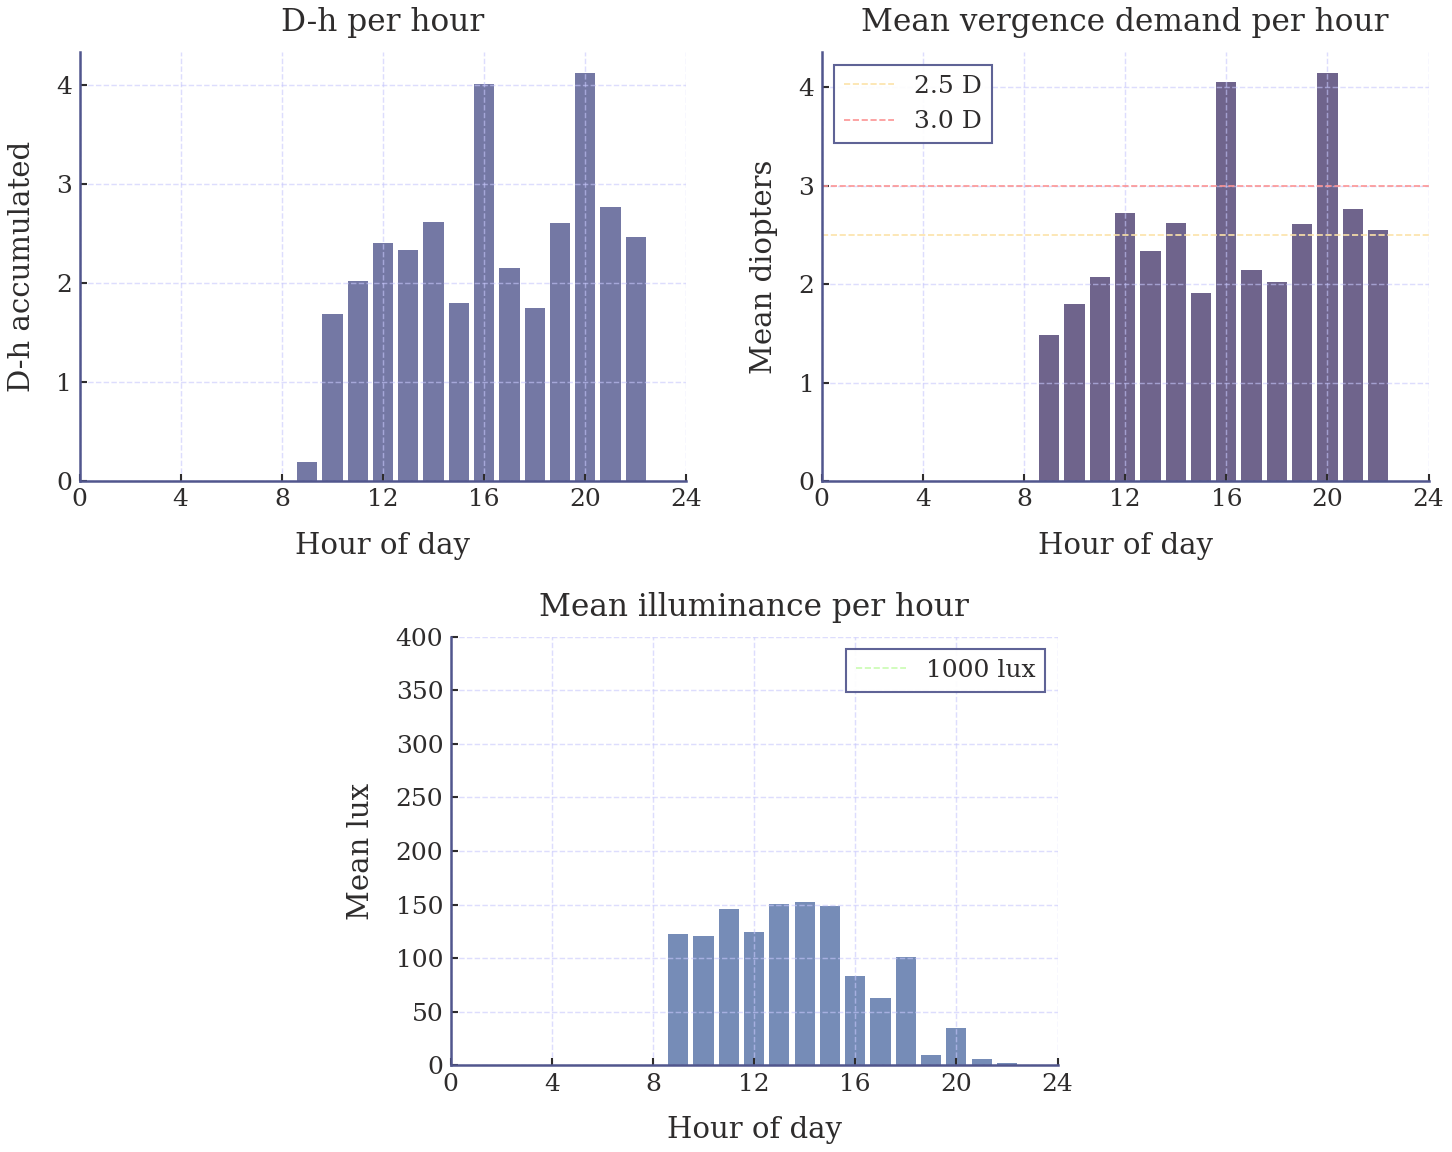

In [11]:
import matplotlib.gridspec as gridspec

df['hour_int'] = df['datetime'].dt.hour

hourly_cols = {'dh_sum': ('dh_inc', 'sum'), 'mean_diopters': ('diopters', 'mean')}
if has_lux:
    hourly_cols['mean_lux'] = ('illumination_lux', 'mean')

hourly = df.groupby('hour_int').agg(**hourly_cols).reset_index()

if has_lux:
    fig = plt.figure(figsize=(10, 8))
    gs_bottom = gridspec.GridSpec(2, 4, figure=fig)
    ax0 = fig.add_subplot(gs_bottom[0, 0:2])
    ax1 = fig.add_subplot(gs_bottom[0, 2:4])
    ax2 = fig.add_subplot(gs_bottom[1, 1:3]) # Centered

    axes = [ax0, ax1, ax2]
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

def fix_hourly_ticks(ax):
    ax.set_xticks(np.arange(0, 25, 4))
    ax.set_xlim(0, 24)

axes[0].bar(hourly['hour_int'], hourly['dh_sum'], color=C_HF, width=0.8, alpha=0.8)
axes[0].set_xlabel('Hour of day', labelpad=10)
axes[0].set_ylabel('D-h accumulated', labelpad=10)
axes[0].set_title('D-h per hour', pad=10)
fix_hourly_ticks(axes[0])

axes[1].bar(hourly['hour_int'], hourly['mean_diopters'], color=C_PURPLE, width=0.8, alpha=0.8)
axes[1].axhline(2.5, color=C_GOLD, linestyle='--', linewidth=0.8, label='2.5 D')
axes[1].axhline(3.0, color=C_OUT,  linestyle='--', linewidth=0.8, label='3.0 D')
axes[1].set_xlabel('Hour of day', labelpad=10)
axes[1].set_ylabel('Mean diopters', labelpad=10)
axes[1].set_title('Mean vergence demand per hour', pad=10)
fix_hourly_ticks(axes[1])
axes[1].legend()

if has_lux:
    axes[2].bar(hourly['hour_int'], hourly['mean_lux'], color=C_BLUE, width=0.8, alpha=0.8)
    axes[2].axhline(1000, color=C_MINT, linestyle='--', linewidth=0.8, label='1000 lux')
    axes[2].set_xlabel('Hour of day', labelpad=10)
    axes[2].set_ylabel('Mean lux', labelpad=10)
    axes[2].set_title('Mean illuminance per hour', pad=10)
    fix_hourly_ticks(axes[2])
    axes[2].set_ylim(0, 400)
    axes[2].legend()

plt.tight_layout()
fig.savefig('figs/app/fig_app_nw_06_hourly.pdf', bbox_inches='tight', dpi=300)
print('Saved: figs/app/fig_app_nw_06_hourly.pdf')
plt.show()

## 10. NRS Weight Functions
Static plots of $w_{\\text{zone}}$ and $w_{\\text{light}}$ as defined in the NRS formula.

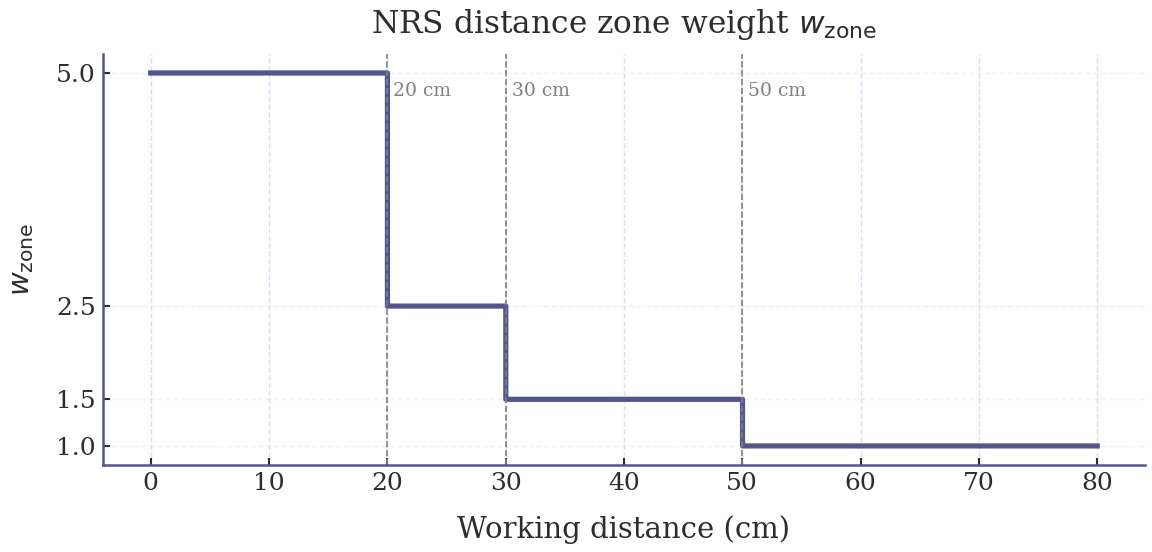

In [12]:
import numpy as np
import matplotlib.pyplot as plt

d_range = np.linspace(0, 80, 2000)

def w_zone_func(d):
    if d < 20:   return 5.0
    elif d < 30: return 2.5
    elif d < 50: return 1.5
    else:        return 1.0

w_zone_vals = [w_zone_func(d) for d in d_range]

fig = plt.figure(figsize=(8, 4))
plt.step(d_range, w_zone_vals, where='post', color=C_HF, linewidth=2.5)
for x, label in [(20, '20 cm'), (30, '30 cm'), (50, '50 cm')]:
    plt.axvline(x, color='grey', linestyle='--', linewidth=0.8)
    plt.text(x + 0.5, 4.75, label, fontsize=9, color='grey')
plt.yticks([1.0, 1.5, 2.5, 5.0], ['1.0', '1.5', '2.5', '5.0'])
plt.xlabel('Working distance (cm)', labelpad=10)
plt.ylabel('$w_{\\mathrm{zone}}$', labelpad=10)
plt.title('NRS distance zone weight $w_{\\mathrm{zone}}$', pad=10)
plt.grid(True, alpha=0.25, axis='y')
plt.tight_layout()
fig.savefig('figs/app/fig_app_nrs_wzone.pdf', bbox_inches='tight', dpi=300)
plt.show()


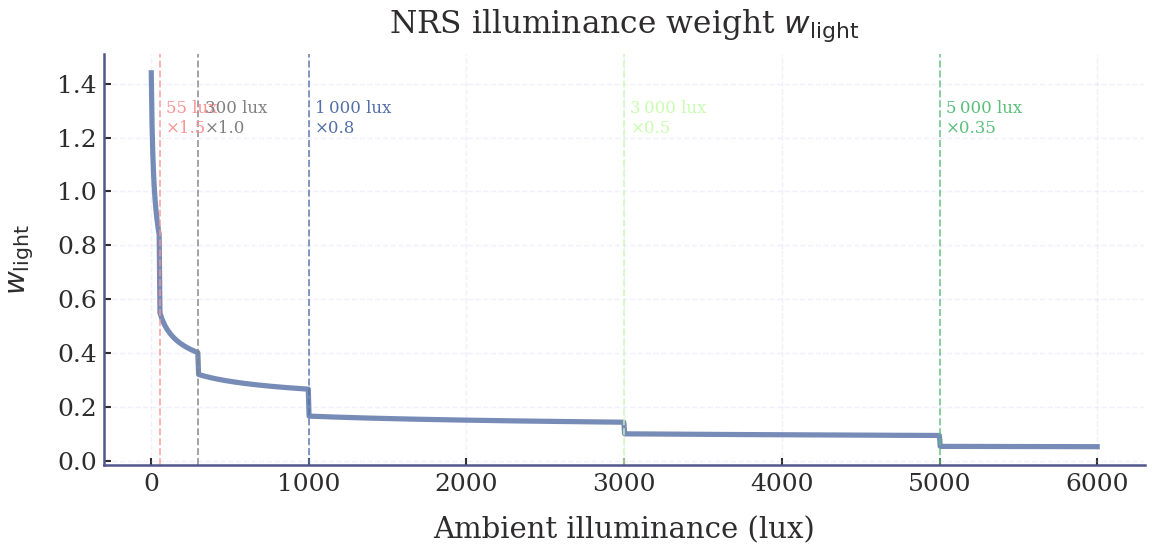

In [13]:
import numpy as np
import matplotlib.pyplot as plt

lux_range = np.linspace(1, 6000, 1200)

def w_light_func(lux):
    if lux <= 55:    tier = 1.50
    elif lux <= 300: tier = 1.00
    elif lux <= 1000: tier = 0.80
    elif lux <= 3000: tier = 0.50
    elif lux <= 5000: tier = 0.35
    else:            tier = 0.20
    return (1 / np.log10(lux + 10)) * tier

w_light_vals = [w_light_func(l) for l in lux_range]

tiers = [
    (55,   '55 lux\n×1.5',     C_OUT),
    (300,  '300 lux\n×1.0',    'grey'),
    (1000, '1\u202f000 lux\n×0.8',  C_BLUE),
    (3000, '3\u202f000 lux\n×0.5',  C_MINT),
    (5000, '5\u202f000 lux\n×0.35', '#5BBF7A'),
]

fig = plt.figure(figsize=(8, 4))
plt.plot(lux_range, w_light_vals, color=C_BLUE, linewidth=2.5, alpha=0.8)
top = max(w_light_vals)
for x, label, color in tiers:
    plt.axvline(x, color=color, linestyle='--', linewidth=0.9, alpha=0.75)
    plt.text(x + 40, top * 0.93, label, fontsize=8, color=color, va='top')
plt.xlabel('Ambient illuminance (lux)', labelpad=10)
plt.ylabel('$w_{\mathrm{light}}$', labelpad=10)
plt.title('NRS illuminance weight $w_{\mathrm{light}}$', pad=10)
plt.grid(True, alpha=0.25)
plt.tight_layout()
fig.savefig('figs/app/fig_app_nrs_wlight.pdf', bbox_inches='tight', dpi=300)
plt.show()

## 11. NRS Computation
Per-sample NRS scores and cumulative integral: $\\text{NRS} = \\overline{\\text{NRS}_i} \\times T$, where $T$ is the session duration in hours.

In [14]:
if not has_lux:
    print("No lux data — skipping NRS computation.")
else:
    df_nrs = df.copy()
    df_nrs['diopters'] = 100 / df_nrs['distance_cm_smooth']

    df_nrs['dist_weight'] = 1.0
    df_nrs.loc[df_nrs['distance_cm_smooth'] < 50, 'dist_weight'] = 1.5
    df_nrs.loc[df_nrs['distance_cm_smooth'] < 30, 'dist_weight'] = 2.5
    df_nrs.loc[df_nrs['distance_cm_smooth'] < 20, 'dist_weight'] = 5.0

    def lux_tier(lux_val):
        if lux_val <= 55:    return 1.50
        elif lux_val <= 300: return 1.00
        elif lux_val <= 1000: return 0.80
        elif lux_val <= 3000: return 0.50
        elif lux_val <= 5000: return 0.35
        else:                return 0.20

    df_nrs['lux_tier']     = df_nrs['illumination_lux'].apply(lux_tier)
    df_nrs['light_weight'] = (1 / np.log10(df_nrs['illumination_lux'] + 10)) * df_nrs['lux_tier']
    df_nrs['nrs_instant']  = df_nrs['diopters'] * df_nrs['dist_weight'] * df_nrs['light_weight']

    nrs_session = df_nrs['nrs_instant'].mean() * duration_h

    print(f"NRS (session) : {nrs_session:.4f} risk-hours")
    print(f"D-h (session) : {dh_total:.4f} D-h")

NRS (session) : 63.5323 risk-hours
D-h (session) : 32.9404 D-h


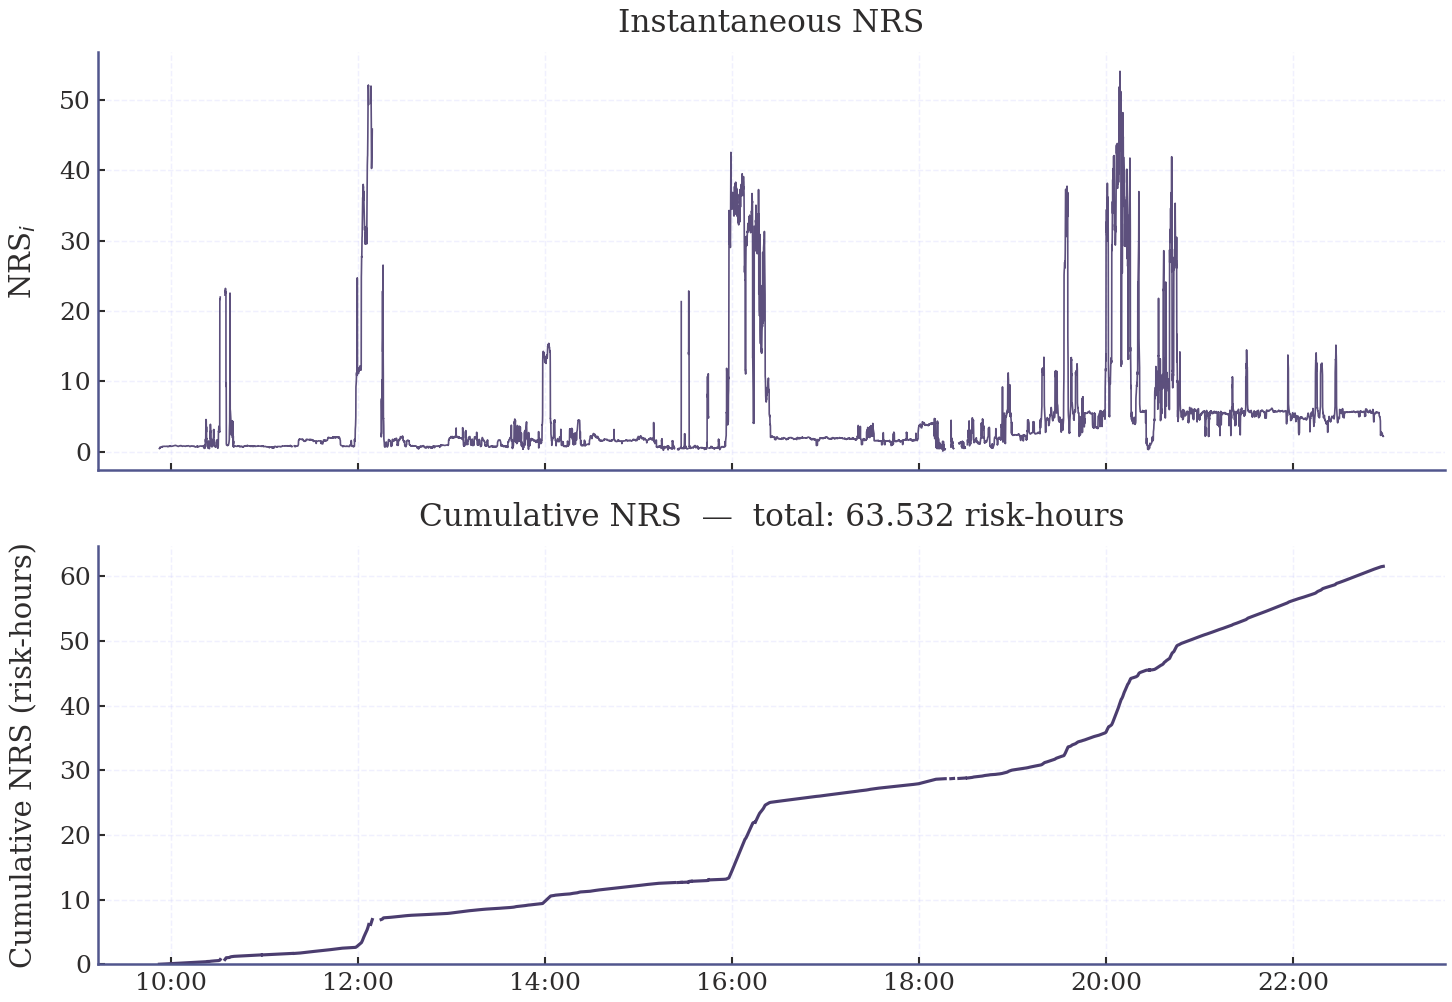

In [15]:
if 'nrs_session' in dir() and nrs_session is not None:
    dt_h = df_nrs['t_sec'].diff().fillna(0) / 3600.0
    df_nrs['nrs_inc'] = df_nrs['nrs_instant'] * dt_h
    df_nrs['nrs_cum'] = df_nrs['nrs_inc'].cumsum()

    x_ax  = df_nrs['datetime'] if use_datetime else df_nrs['t_sec']
    x_fmt = mdates.DateFormatter('%H:%M') if use_datetime else None
    x_lbl = '' if use_datetime else 'Seconds from session start'

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    axes[0].plot(x_ax, df_nrs['nrs_instant'], color='#4B3D6F', linewidth=0.8, alpha=0.9)
    axes[0].set_ylabel('NRS$_i$', labelpad=10)
    axes[0].set_title('Instantaneous NRS', pad=10)
    axes[0].grid(True, alpha=0.25)

    axes[1].plot(x_ax, df_nrs['nrs_cum'], color='#4B3D6F', linewidth=1.5)
    axes[1].set_ylabel('Cumulative NRS (risk-hours)', labelpad=10)
    axes[1].set_title(f'Cumulative NRS  —  total: {nrs_session:.3f} risk-hours', pad=10)
    axes[1].set_ylim(0, df_nrs['nrs_cum'].dropna().max() * 1.05)
    if x_fmt: axes[1].xaxis.set_major_formatter(x_fmt)
    axes[1].set_xlabel(x_lbl, labelpad=10)
    axes[1].grid(True, alpha=0.25)

    plt.tight_layout()
    fig.savefig('figs/app/fig_app_nw_07_nrs_cumulative.pdf', bbox_inches='tight', dpi=300)
    plt.show()


## 12. Session Summary
Prints a formatted summary of all computed metrics: D-h, mean vergence, illuminance statistics, and NRS.

In [16]:
print("\u2550" * 48)
print("  SESSION SUMMARY")
print("\u2550" * 48)
if use_datetime:
    print(f"  Date/start    : {first_dt.strftime('%Y-%m-%d  %H:%M UTC')}")
print(f"  Duration      : {duration_h:.2f} h  ({duration_s/60:.0f} min)")
print(f"  Samples       : {sample_count}")
print()
print("\u2500\u2500 Diopter-hours \u2500" * 2)
print(f"  D-h           : {dh_total:.4f} D-h")
print(f"  Mean vergence : {df['diopters'].mean():.3f} D")
if has_lux:
    print()
    print("\u2500\u2500 Illuminance \u2500" * 2)
    print(f"  Mean lux      : {df['illumination_lux'].mean():.1f}")
    if 'mean_lux_nw' in dir():
        print(f"  Lux (NW only) : {mean_lux_nw:.1f}")
    if 'outdoor_min' in dir():
        print(f"  Outdoor time  : {outdoor_min:.1f} min  ({outdoor_frac*100:.1f}%)")
    if 'nw_low_light_sec' in dir():
        print(f"  NW + low light: {nw_low_light_sec/60:.1f} min")
if 'nrs_session' in dir() and nrs_session is not None:
    print()
    print("\u2500\u2500 Nearwork Risk Score \u2500" * 2)
    print(f"  NRS           : {nrs_session:.4f} risk-hours")

════════════════════════════════════════════════
  SESSION SUMMARY
════════════════════════════════════════════════
  Date/start    : 2026-06-07  09:52 UTC
  Duration      : 13.09 h  (786 min)
  Samples       : 47136

── Diopter-hours ─── Diopter-hours ─
  D-h           : 32.9404 D-h
  Mean vergence : 2.598 D

── Illuminance ─── Illuminance ─
  Mean lux      : 88.5
  Lux (NW only) : 55.7
  Outdoor time  : 0.1 min  (0.0%)
  NW + low light: 226.9 min

── Nearwork Risk Score ─── Nearwork Risk Score ─
  NRS           : 63.5323 risk-hours
